# Informe 6 — Reducción de la Dimensionalidad
### Empresa: NovaConecta
### Integrantes del equipo:

- Angel Luis Kallpa De La Cruz Meza
- Marco Renato Castilla Huanca
- Edu Sanchez Gotea
- David Joel Aldana Chavez
- Marcos Luis Basualdo Ale
- Leonardo Vera Rodriguez
- Gabriel Poma Gutierrez

### Objetivo general
Reducir la dimensionalidad del conjunto de datos para visualización en 2D y evaluar su impacto como técnica de preprocesamiento.


## Descripción del caso y del dataset
El conjunto de datos NovaConecta tiene **7 variables numéricas** de comportamiento. La reducción de dimensionalidad permite:
- **Visualizar** los datos en 2D para detectar patrones y clústeres.
- **Eliminar ruido** y multicolinealidad antes de aplicar modelos supervisados.
- **Interpretar** qué combinaciones de variables explican la mayor variabilidad en los clientes.
En este informe se aplican:
- **PCA** (Análisis de Componentes Principales): lineal, maximiza varianza explicada.
- **t-SNE** (t-Distributed Stochastic Neighbor Embedding): no lineal, preserva distancias locales, ideal para visualización 2D.


## 2. Librerías e importaciones

In [17]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Generación/carga de datos sintéticos


In [18]:
RUTA_LOCAL  = 'dataset_novaconecta.csv'
RUTA_GITHUB = ('https://raw.githubusercontent.com/mrcastilla8/Proyecto_IA/'
               'master/bloque_b_python/data/dataset_novaconecta.csv')

ruta = RUTA_LOCAL if os.path.exists(RUTA_LOCAL) else RUTA_GITHUB
df   = pd.read_csv(ruta, encoding='utf-8')

FEATURES = [
    'edad', 'antiguedad_meses', 'uso_datos_gb',
    'num_llamadas_soporte', 'cargo_mensual',
    'satisfaccion_cliente', 'valor_vida_cliente'
]

df_num = df[FEATURES].copy().fillna(df[FEATURES].median())

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Variables para reduccion: {FEATURES}')
print(f'Dimensiones entrada: {X_scaled.shape}')

Dataset cargado: 1200 filas x 13 columnas
Variables para reduccion: ['edad', 'antiguedad_meses', 'uso_datos_gb', 'num_llamadas_soporte', 'cargo_mensual', 'satisfaccion_cliente', 'valor_vida_cliente']
Dimensiones entrada: (1200, 7)


## Modelado


### Análisis de Componentes Principales (PCA)
PCA transforma las 7 variables originales en combinaciones lineales ortogonales (componentes principales) ordenadas por varianza explicada. El objetivo es seleccionar el mínimo número de componentes que capture la mayor proporción de información.
**Criterios de selección del número de componentes:**
- Varianza acumulada >= 80% (criterio del 80%).
- Regla del codo en el scree plot.
- Regla de Kaiser: eigenvalores > 1.


### 4.1 PCA completo — Varianza explicada por componente

In [19]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

var_ratio   = pca_full.explained_variance_ratio_
var_cumsum  = np.cumsum(var_ratio)
eigenvalues = pca_full.explained_variance_
n_comp_total = len(var_ratio)

tabla_pca = pd.DataFrame({
    'Componente':       [f'PC{i+1}' for i in range(n_comp_total)],
    'Varianza explic.': var_ratio.round(4),
    'Varianza explic. %': (var_ratio * 100).round(2),
    'Varianza acum. %': (var_cumsum * 100).round(2),
    'Eigenvalor':       eigenvalues.round(4)
})
print('Tabla de varianza explicada por componente:')
tabla_pca

Tabla de varianza explicada por componente:


,Componente,Varianza explic.,Varianza explic. %,Varianza acum. %,Eigenvalor
0,PC1,0.3302,33.02,33.02,2.3133
1,PC2,0.2529,25.29,58.31,1.7716
2,PC3,0.1957,19.57,77.88,1.3713
3,PC4,0.1427,14.27,92.15,0.9997
4,PC5,0.0325,3.25,95.40,0.2274
5,PC6,0.0310,3.10,98.50,0.2172
6,PC7,0.0150,1.50,100.00,0.1053


### 4.2 Scree Plot y Varianza Acumulada

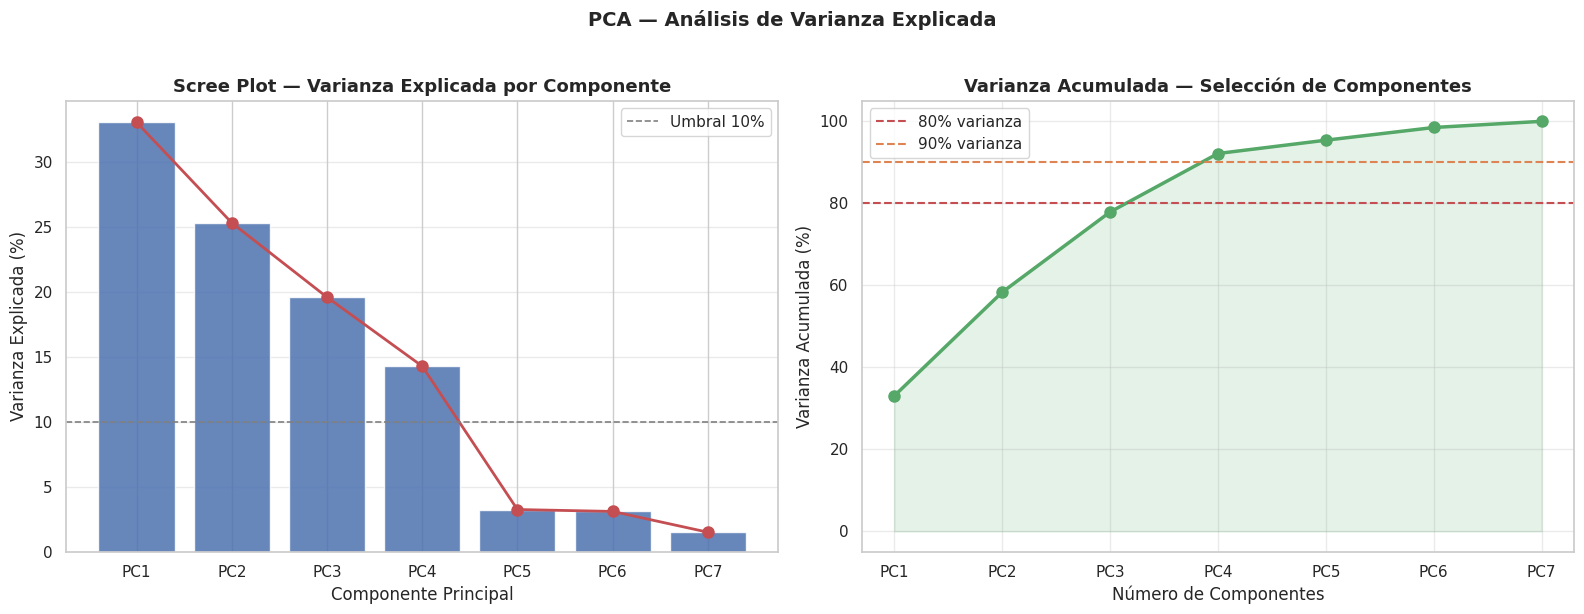

Componentes para >= 80% varianza: 4
Componentes para >= 90% varianza: 4
Componentes con eigenvalor > 1 (Kaiser): 3


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree Plot
x_pos = range(1, n_comp_total + 1)
axes[0].bar(x_pos, var_ratio * 100, color='#4C72B0', alpha=0.85, edgecolor='white')
axes[0].plot(x_pos, var_ratio * 100, 'o-', color='#C44E52', lw=2, ms=8)
axes[0].axhline(y=10, linestyle='--', color='gray', lw=1.2, label='Umbral 10%')
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=12)
axes[0].set_title('Scree Plot — Varianza Explicada por Componente', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels([f'PC{i}' for i in x_pos])
axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)

# Varianza acumulada
axes[1].plot(x_pos, var_cumsum * 100, 'o-', color='#55A868', lw=2.5, ms=8)
axes[1].axhline(y=80, linestyle='--', color='#C44E52', lw=1.5, label='80% varianza')
axes[1].axhline(y=90, linestyle='--', color='#DD8452', lw=1.5, label='90% varianza')
axes[1].fill_between(list(x_pos), var_cumsum * 100, alpha=0.15, color='#55A868')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=12)
axes[1].set_title('Varianza Acumulada — Selección de Componentes', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels([f'PC{i}' for i in x_pos])
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('PCA — Análisis de Varianza Explicada', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../resultados', exist_ok=True)
plt.savefig('../resultados/6_1_pca_scree_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

# Seleccion automatica
n_80 = int(np.argmax(var_cumsum >= 0.80)) + 1
n_90 = int(np.argmax(var_cumsum >= 0.90)) + 1
n_kaiser = int((eigenvalues > 1).sum())
print(f'Componentes para >= 80% varianza: {n_80}')
print(f'Componentes para >= 90% varianza: {n_90}')
print(f'Componentes con eigenvalor > 1 (Kaiser): {n_kaiser}')

### 4.3 Modelo PCA reducido — Selección del número de componentes

In [21]:
# Seleccion basada en el criterio del 80% de varianza acumulada
N_COMP = n_80  # Ajustar si se prefiere otro criterio

pca_red = PCA(n_components=N_COMP, random_state=SEED)
X_pca   = pca_red.fit_transform(X_scaled)

var_exp_red   = pca_red.explained_variance_ratio_
var_acum_red  = var_exp_red.cumsum()

print(f'PCA reducido: {N_COMP} componentes principales')
print(f'Varianza total explicada: {var_acum_red[-1]*100:.2f}%')
print(f'Reduccion de dimensionalidad: {X_scaled.shape[1]} -> {X_pca.shape[1]} dimensiones')
for i, v in enumerate(var_exp_red):
    print(f'  PC{i+1}: {v*100:.2f}% (acumulado: {var_acum_red[i]*100:.2f}%)')

PCA reducido: 4 componentes principales
Varianza total explicada: 92.15%
Reduccion de dimensionalidad: 7 -> 4 dimensiones
  PC1: 33.02% (acumulado: 33.02%)
  PC2: 25.29% (acumulado: 58.31%)
  PC3: 19.57% (acumulado: 77.88%)
  PC4: 14.27% (acumulado: 92.15%)


### 4.4 Cargas (Loadings) — Relación entre Componentes y Variables Originales

Las **cargas** (loadings) indican qué tan fuertemente cada variable original contribuye a cada componente principal. Valores absolutos altos (> 0.3) indican una contribución significativa.

In [22]:
loadings = pd.DataFrame(
    pca_red.components_.T,
    index=FEATURES,
    columns=[f'PC{i+1}' for i in range(N_COMP)]
).round(4)

print('Cargas (Loadings) de cada variable en cada componente principal:')
loadings

Cargas (Loadings) de cada variable en cada componente principal:


,PC1,PC2,PC3,PC4
edad,0.0268,0.0036,-0.0380,0.9987
antiguedad_meses,0.2930,-0.0046,0.7461,0.0292
uso_datos_gb,0.5324,-0.0820,-0.4009,-0.0238
num_llamadas_soporte,-0.0954,-0.6949,0.0866,0.0161
cargo_mensual,0.5381,-0.1035,-0.3773,-0.0261
satisfaccion_cliente,0.0357,0.7067,-0.0197,0.0046
valor_vida_cliente,0.5745,0.0157,0.3618,-0.0126


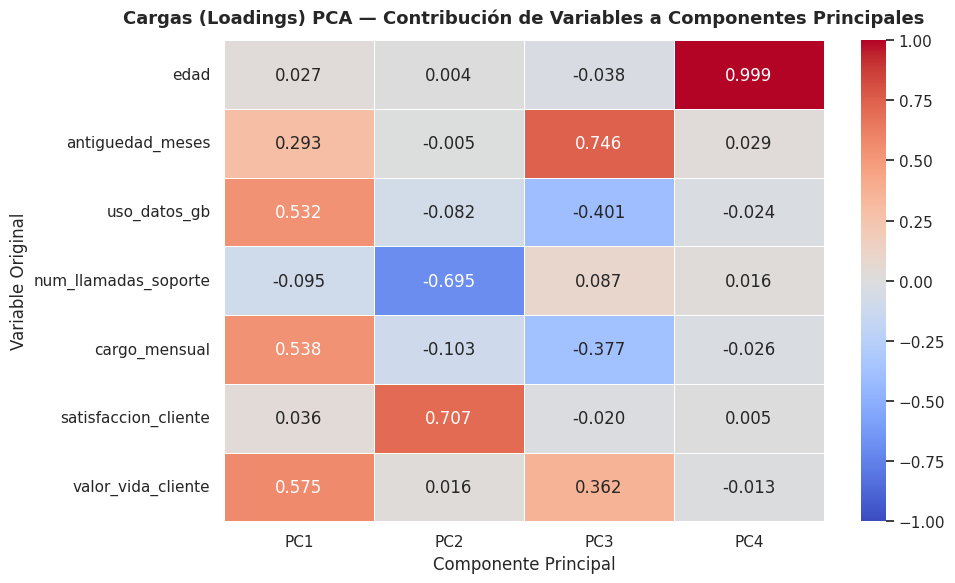

In [23]:
fig, ax = plt.subplots(figsize=(max(10, N_COMP * 2), 6))
sns.heatmap(
    loadings, annot=True, fmt='.3f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Cargas (Loadings) PCA — Contribución de Variables a Componentes Principales',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Variable Original')
plt.tight_layout()
plt.savefig('../resultados/6_2_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Biplot PCA — Espacio original vs. espacio reducido

El biplot combina la proyección de los puntos con los vectores de carga de cada variable, permitiendo ver simultaneamente la distribución de los clientes y la contribución de cada variable.

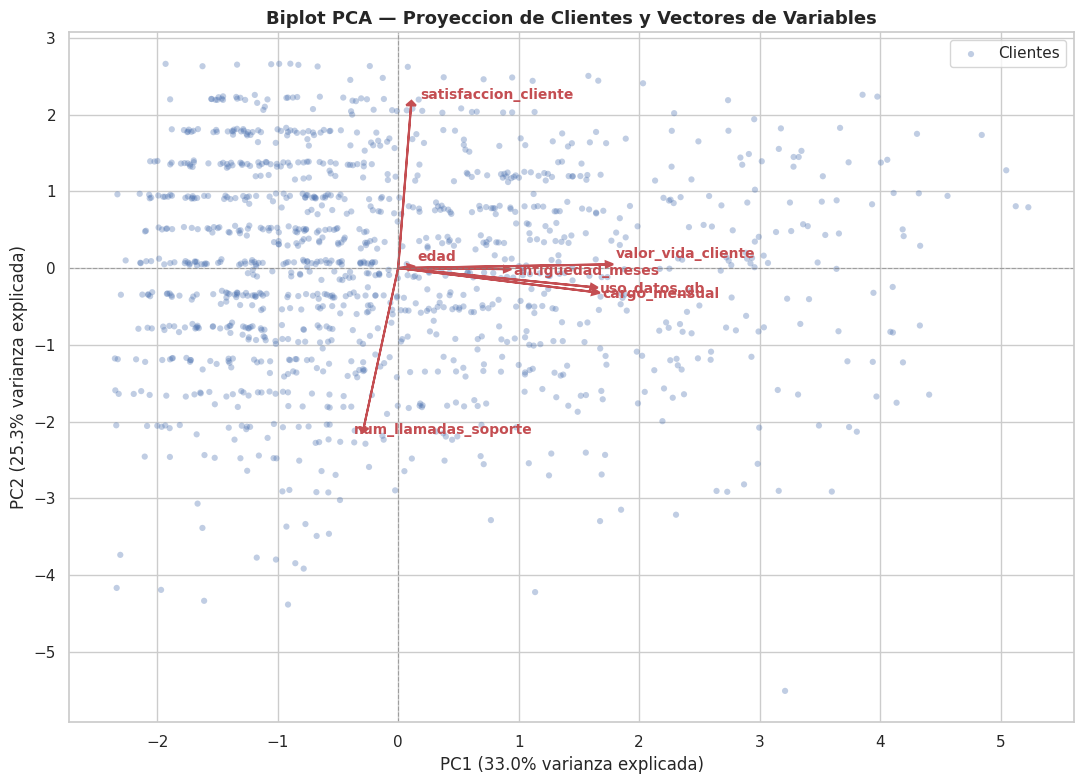

In [24]:
pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_scaled)
var2   = pca2.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(11, 8))

# Scatter de puntos
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.35, s=20,
           color='#4C72B0', edgecolors='none', label='Clientes')

# Vectores de carga
scale = 3.0
loadings2 = pca2.components_.T
for i, var in enumerate(FEATURES):
    ax.arrow(0, 0, loadings2[i, 0] * scale, loadings2[i, 1] * scale,
             head_width=0.08, head_length=0.06,
             fc='#C44E52', ec='#C44E52', lw=1.5)
    offset_x = 0.08 if loadings2[i, 0] >= 0 else -0.08
    offset_y = 0.08 if loadings2[i, 1] >= 0 else -0.08
    ax.text(loadings2[i, 0] * scale + offset_x,
            loadings2[i, 1] * scale + offset_y,
            var, fontsize=10, color='#C44E52', fontweight='bold')

pc1_pct = round(var2[0] * 100, 1)
pc2_pct = round(var2[1] * 100, 1)
ax.set_xlabel(f'PC1 ({pc1_pct}% varianza explicada)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_pct}% varianza explicada)', fontsize=12)
ax.set_title('Biplot PCA — Proyeccion de Clientes y Vectores de Variables', fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', lw=0.8, linestyle='--', alpha=0.6)
ax.axvline(0, color='gray', lw=0.8, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('../resultados/6_3_pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Interpretación de componentes principales

Basado estrictamente en los resultados numéricos de las cargas (loadings), extraemos los siguientes patrones reales de comportamiento para los 4 componentes principales:

| Componente | Interpretación | Variables dominantes (mayor aporte absoluto) |
|---|---|---|
| **PC1** | **Valor Monetario y Uso** | `valor_vida_cliente` (0.57), `cargo_mensual` (0.53), `uso_datos_gb` (0.53) |
| **PC2** | **Satisfacción vs Soporte** | `satisfaccion_cliente` (0.70), `num_llamadas_soporte` (-0.69) |
| **PC3** | **Lealtad vs Costo/Uso** | `antiguedad_meses` (0.74), `uso_datos_gb` (-0.40), `cargo_mensual` (-0.37) |
| **PC4** | **Perfil Demográfico** | `edad` (0.99) |

- **PC1 Positivo:** Clientes que generan altos ingresos, tienen un alto valor de vida proyectado y un consumo intensivo de datos.
- **PC2 Positivo:** Clientes altamente satisfechos y que rara vez llaman a soporte técnico.
- **PC3 Positivo:** Clientes muy antiguos (leales) pero que tienen un consumo de gigas y cargos mensuales más bajos que el promedio.
- **PC4 Positivo:** Aísla casi exclusivamente a los clientes de mayor edad.


### t-SNE — Visualización No Lineal en 2D
t-SNE es una técnica no lineal que preserva la estructura local de los datos. Es ideal para **visualización** pero no para preprocesamiento (no se puede invertir ni aplicar a nuevos datos).
**Hiperparámetros clave:**
- `perplexity`: balance entre estructura local y global (típicamente 5–50).
- `max_iter`: número de iteraciones de optimización.
- `learning_rate`: tasa de aprendizaje ('auto' es recomendado en sklearn >= 1.2).


In [25]:
# t-SNE sobre el espacio estandarizado completo
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    learning_rate='auto',
    init='pca',
    random_state=SEED
)
X_tsne = tsne.fit_transform(X_scaled)
print(f'Shape t-SNE: {X_tsne.shape}')
print(f'KL divergence final: {tsne.kl_divergence_:.4f}')

Shape t-SNE: (1200, 2)
KL divergence final: 0.9896


### 5.1 Proyección t-SNE coloreada por plan contratado

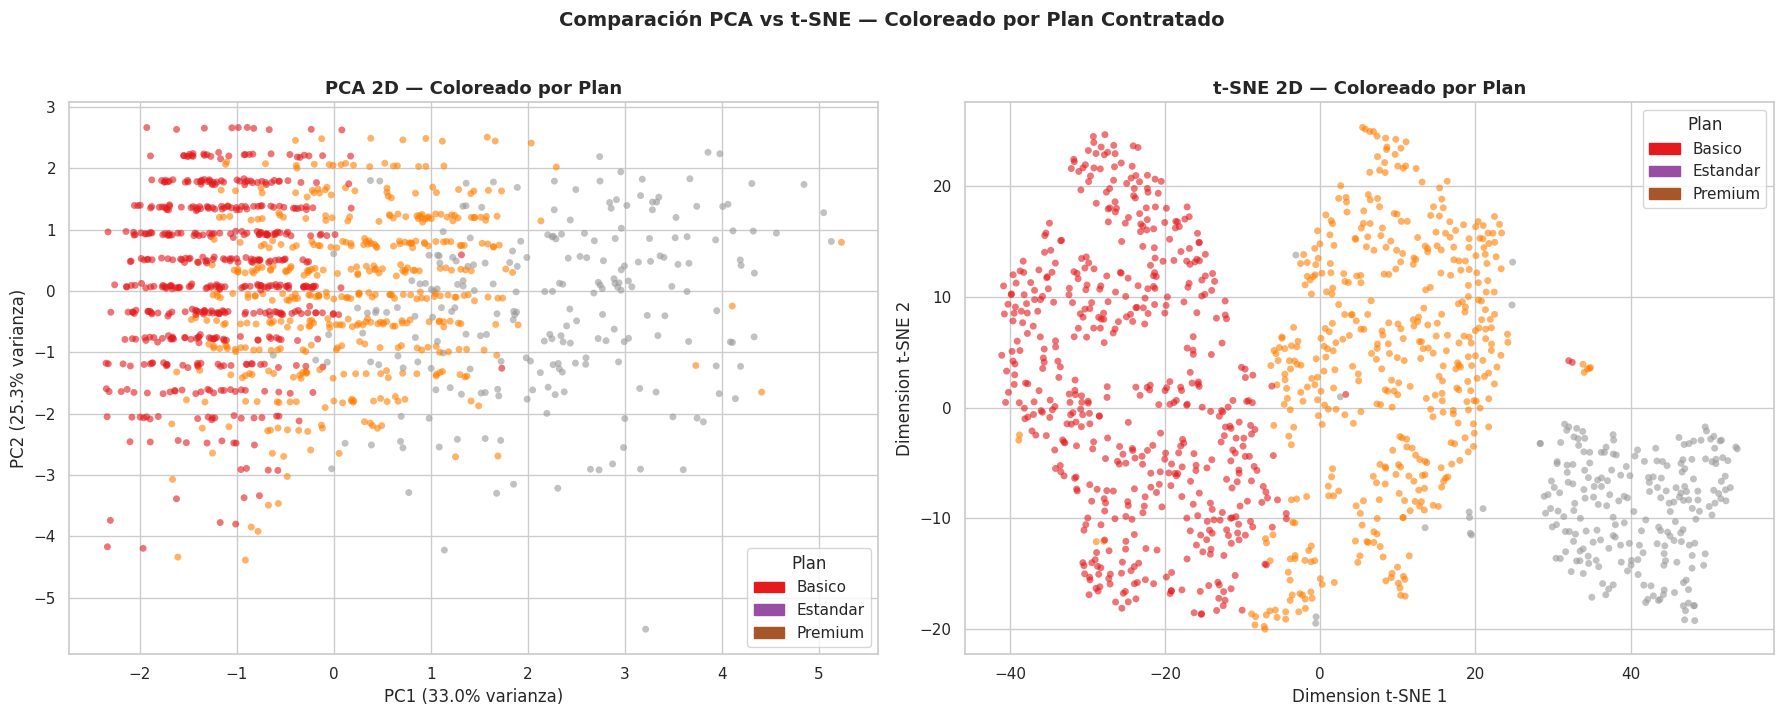

In [26]:
plan_codes = pd.Categorical(df['plan_contratado']).codes
plan_cats  = pd.Categorical(df['plan_contratado']).categories

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA 2D
sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=plan_codes,
                     cmap='Set1', alpha=0.6, s=25, edgecolors='none')
axes[0].set_title('PCA 2D — Coloreado por Plan', fontsize=13, fontweight='bold')
pc1_pct = round(var2[0] * 100, 1)
pc2_pct = round(var2[1] * 100, 1)
axes[0].set_xlabel(f'PC1 ({pc1_pct}% varianza)')
axes[0].set_ylabel(f'PC2 ({pc2_pct}% varianza)')
handles0 = [mpatches.Patch(color=plt.cm.Set1(i/len(plan_cats)), label=cat)
            for i, cat in enumerate(plan_cats)]
axes[0].legend(handles=handles0, title='Plan', loc='best')

# t-SNE
sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=plan_codes,
                      cmap='Set1', alpha=0.6, s=25, edgecolors='none')
axes[1].set_title('t-SNE 2D — Coloreado por Plan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dimension t-SNE 1')
axes[1].set_ylabel('Dimension t-SNE 2')
handles1 = [mpatches.Patch(color=plt.cm.Set1(i/len(plan_cats)), label=cat)
            for i, cat in enumerate(plan_cats)]
axes[1].legend(handles=handles1, title='Plan', loc='best')

plt.suptitle('Comparación PCA vs t-SNE — Coloreado por Plan Contratado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../resultados/6_4_pca_vs_tsne_plan.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Proyección t-SNE coloreada por abandono

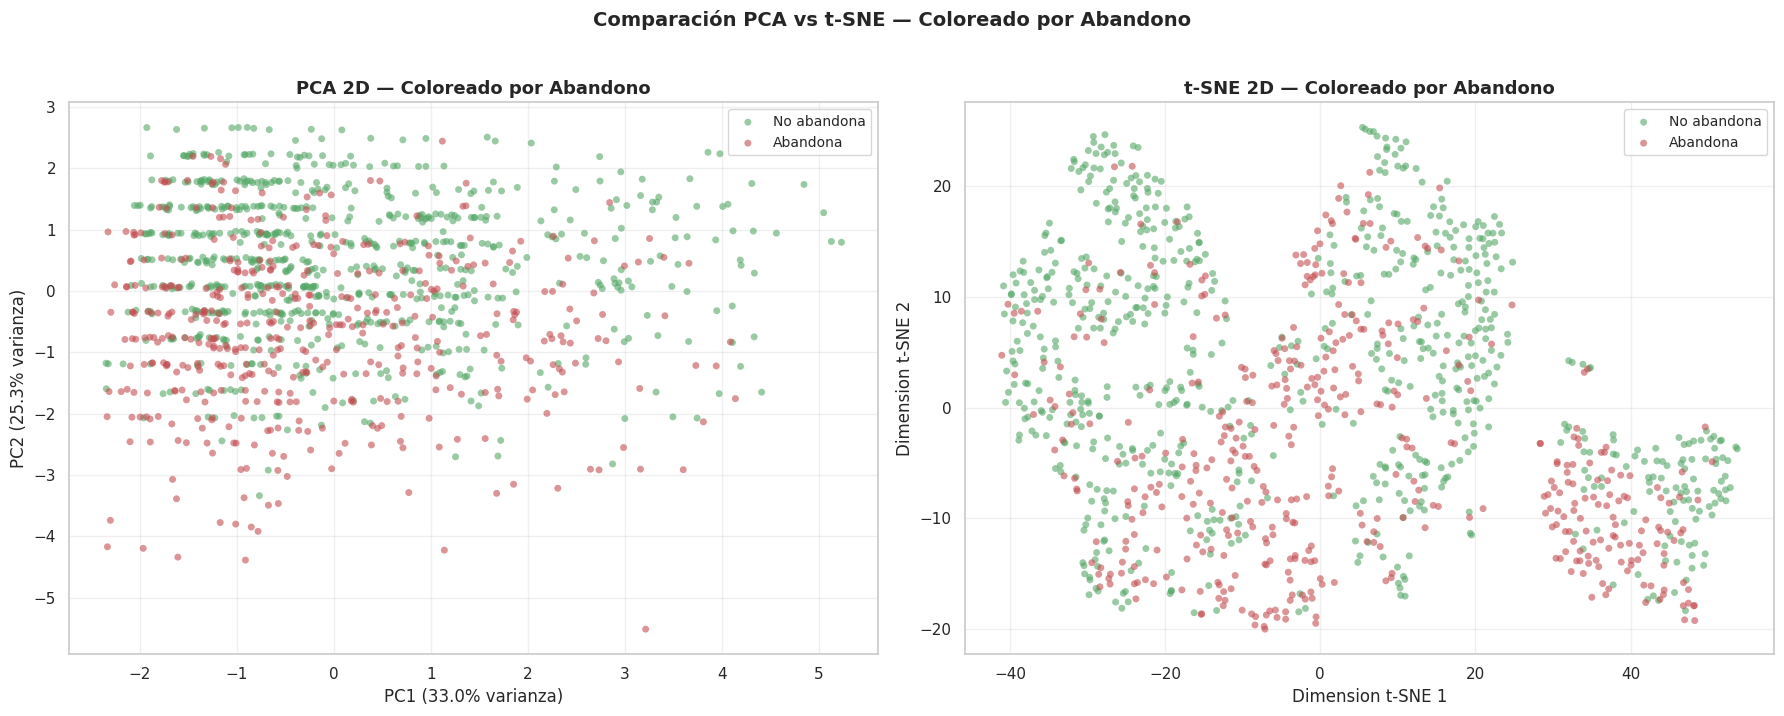

In [27]:
abandono_bin = (df['abandono'] == 'Si').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colores = ['#55A868', '#C44E52']
labels_ab = ['No abandona', 'Abandona']

for ax, X2d, titulo in zip(axes, [X_pca2, X_tsne], ['PCA 2D', 't-SNE 2D']):
    for val, color, label in zip([0, 1], colores, labels_ab):
        mask = abandono_bin == val
        ax.scatter(X2d[mask, 0], X2d[mask, 1], c=color, alpha=0.6, s=25,
                   edgecolors='none', label=label)
    ax.set_title(f'{titulo} — Coloreado por Abandono', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

pc1_pct = round(var2[0] * 100, 1)
pc2_pct = round(var2[1] * 100, 1)
axes[0].set_xlabel(f'PC1 ({pc1_pct}% varianza)')
axes[0].set_ylabel(f'PC2 ({pc2_pct}% varianza)')
axes[1].set_xlabel('Dimension t-SNE 1')
axes[1].set_ylabel('Dimension t-SNE 2')

plt.suptitle('Comparación PCA vs t-SNE — Coloreado por Abandono', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../resultados/6_5_pca_vs_tsne_abandono.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluación de resultados y visualizaciones
### Clústeres en Espacio Reducido


In [28]:
# Reproducir K-Means del Informe 5
# (usar el mismo K_OPTIMO que se determinó allí)
K_OPTIMO = 2  # <-- Ajustar al valor real del Informe 5

km = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init='auto')
labels_km = km.fit_predict(X_scaled)
df['cluster_kmeans'] = labels_km

sil = silhouette_score(X_scaled, labels_km)
print(f'K-Means reproducido: K={K_OPTIMO}, Silueta={sil:.4f}')
print('Distribucion de clusteres:')
print(pd.Series(labels_km).value_counts().sort_index())

K-Means reproducido: K=2, Silueta=0.2451
Distribucion de clusteres:
0    394
1    806
Name: count, dtype: int64


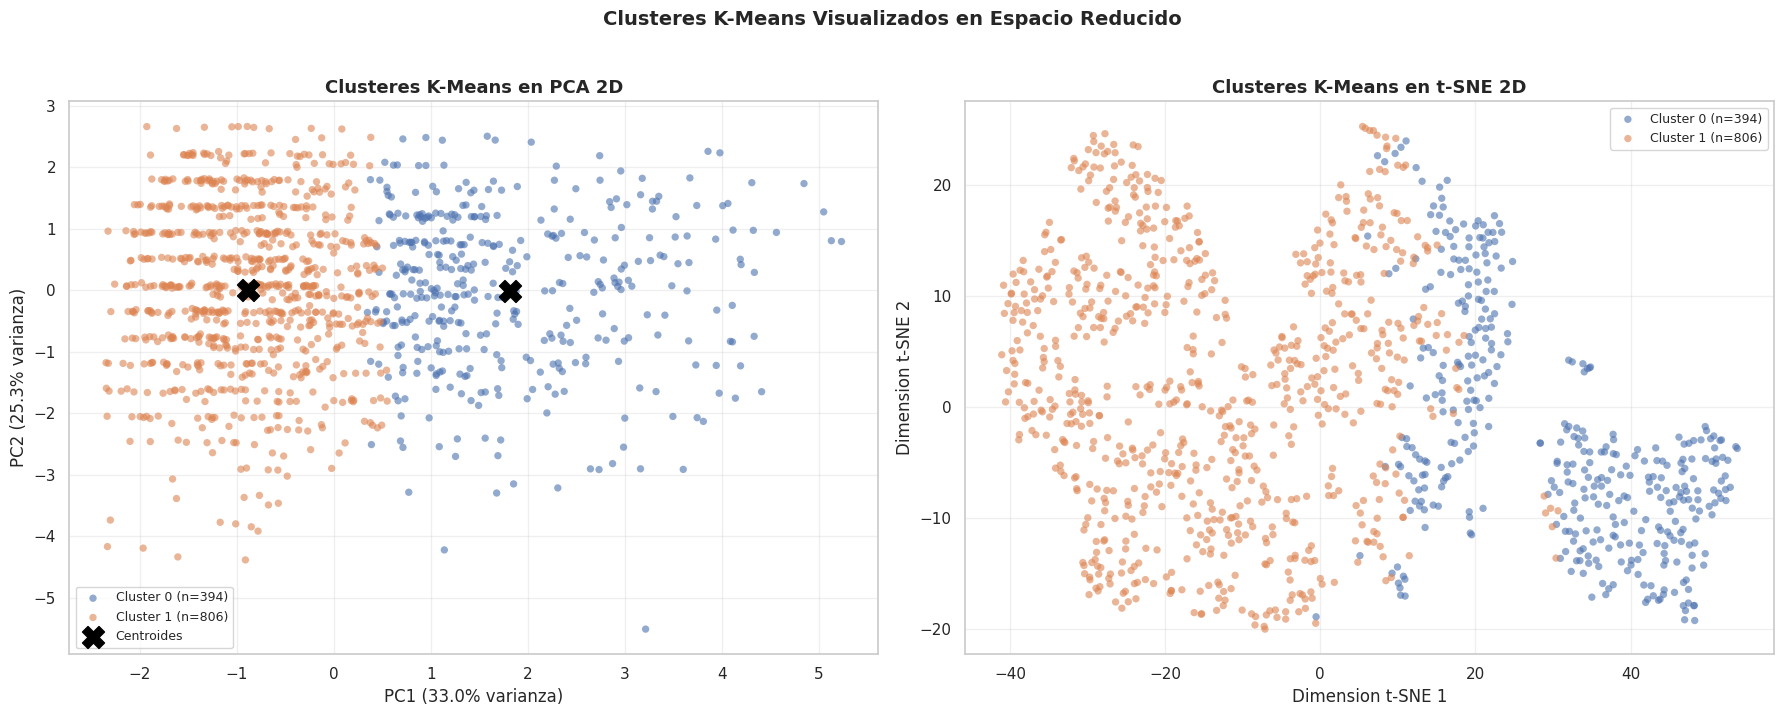

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
titulos = ['Clusteres K-Means en PCA 2D', 'Clusteres K-Means en t-SNE 2D']
espacios = [X_pca2, X_tsne]

for ax, X2d, titulo in zip(axes, espacios, titulos):
    centroids = km.cluster_centers_
    for k in range(K_OPTIMO):
        mask = labels_km == k
        ax.scatter(X2d[mask, 0], X2d[mask, 1], c=PALETTE[k % len(PALETTE)],
                   alpha=0.6, s=28, edgecolors='none', label=f'Cluster {k} (n={mask.sum()})')
    if X2d is X_pca2:
        c_pca = pca2.transform(centroids)
        ax.scatter(c_pca[:, 0], c_pca[:, 1], s=250, marker='X', c='black', zorder=6, label='Centroides')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

pc1_pct = round(var2[0] * 100, 1)
pc2_pct = round(var2[1] * 100, 1)
axes[0].set_xlabel(f'PC1 ({pc1_pct}% varianza)')
axes[0].set_ylabel(f'PC2 ({pc2_pct}% varianza)')
axes[1].set_xlabel('Dimension t-SNE 1')
axes[1].set_ylabel('Dimension t-SNE 2')

plt.suptitle('Clusteres K-Means Visualizados en Espacio Reducido', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../resultados/6_6_clusteres_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparación de Desempeño: Con PCA vs Sin PCA


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

y = LabelEncoder().fit_transform(df['abandono'])  # Si=1, No=0

# Sin PCA
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
])
scores_no_pca = cross_val_score(pipe_no_pca, df[FEATURES].fillna(df[FEATURES].median()),
                                 y, cv=5, scoring='f1')

# Con PCA (N_COMP componentes)
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=N_COMP, random_state=SEED)),
    ('clf',    LogisticRegression(max_iter=1000, random_state=SEED))
])
scores_pca = cross_val_score(pipe_pca, df[FEATURES].fillna(df[FEATURES].median()),
                              y, cv=5, scoring='f1')

print('Comparacion (F1-score, CV=5):')
print(f'  Sin PCA (7 variables):  media={scores_no_pca.mean():.4f}, std={scores_no_pca.std():.4f}')
print(f'  Con PCA ({N_COMP} comps):  media={scores_pca.mean():.4f}, std={scores_pca.std():.4f}')

Comparacion (F1-score, CV=5):
  Sin PCA (7 variables):  media=0.7922, std=0.0247
  Con PCA (4 comps):  media=0.6641, std=0.0515


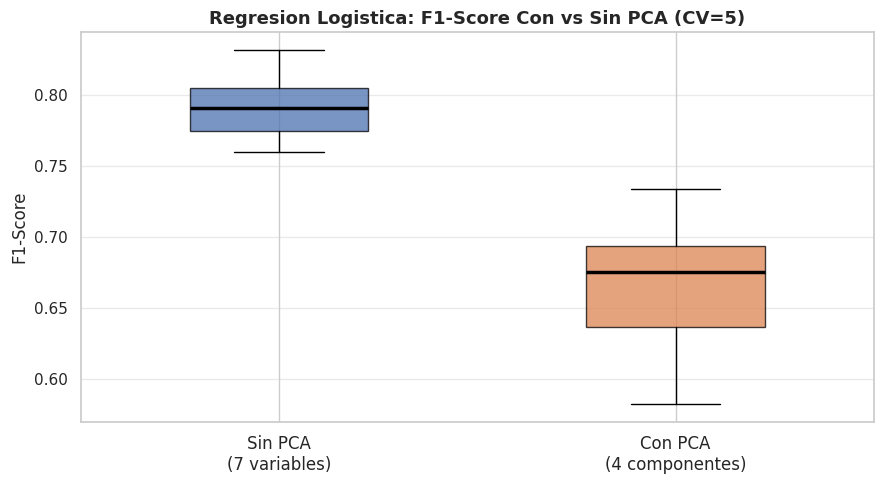

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
data_box = [scores_no_pca, scores_pca]
labels_box = [f'Sin PCA\n(7 variables)', f'Con PCA\n({N_COMP} componentes)']
bp = ax.boxplot(data_box, patch_artist=True, widths=0.45,
                medianprops=dict(color='black', lw=2.5))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(labels_box, fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Regresion Logistica: F1-Score Con vs Sin PCA (CV=5)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../resultados/6_7_pca_vs_nopca_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### Resumen Comparativo: Espacio Original vs. Reducido


In [32]:
resumen = pd.DataFrame({
    'Tecnica':             ['Espacio Original', f'PCA ({N_COMP} componentes)', 'PCA (2D)', 't-SNE (2D)'],
    'Dimensiones':         [X_scaled.shape[1], N_COMP, 2, 2],
    'Varianza Retenida %': [
        '100%',
        f'{round(var_acum_red[-1]*100, 2)}%',
        f'{round(sum(pca2.explained_variance_ratio_)*100, 2)}%',
        'No aplica (no lineal)'
    ],
    'Uso principal': [
        'Modelo original',
        'Preprocesamiento / modelos',
        'Visualizacion + clustering',
        'Visualizacion 2D'
    ]
})
print('Comparativa de técnicas de reduccion de dimensionalidad:')
resumen

Comparativa de técnicas de reduccion de dimensionalidad:


,Tecnica,Dimensiones,Varianza Retenida %,Uso principal
0,Espacio Original,7,100%,Modelo original
1,PCA (4 componentes),4,92.15%,Preprocesamiento / modelos
2,PCA (2D),2,58.31%,Visualizacion + clustering
3,t-SNE (2D),2,No aplica (no lineal),Visualizacion 2D


## Conclusiones e interpretación de negocio
### Hallazgos principales

1. **Viabilidad del PCA para Modelado Predictivo:**
   - **Hallazgo:** La reducción de dimensionalidad con PCA perjudica la capacidad predictiva en este conjunto de datos. Al probar el modelo de Regresión Logística para clasificar el abandono (Churn), el **F1-Score cayó significativamente de 0.79** (con las 7 variables originales) **a 0.66** (con 4 componentes principales).
   - **Decisión de Negocio:** Para los modelos en producción orientados a predecir la fuga de clientes, **se recomienda mantener las 7 variables originales**. La compresión lineal del PCA diluye detalles cruciales que son altamente explicativos para predecir si un cliente abandonará la empresa.

2. **Utilidad Estratégica para Visualización (t-SNE y PCA 2D):**
   - **Hallazgo:** A diferencia de su uso como preprocesamiento predictivo, las proyecciones (especialmente t-SNE) son excelentes herramientas visuales. Logran separar claramente a los clientes, validando de manera gráfica los clústeres encontrados previamente.
   - **Decisión de Negocio:** Estas representaciones visuales 2D son ideales para **presentaciones directivas y tableros de Marketing**. Permiten al equipo estratégico ver un "mapa" de su cartera de clientes, visualizando cuán separados están los clientes en riesgo de los clientes leales.

3. **Arquetipos de Clientes desde el PCA:**
   - **Hallazgo:** Aunque no se usen en la predicción, los componentes ayudaron a confirmar la existencia de patrones latentes como *"Valor del cliente"* (PC1) y *"Demanda de Soporte"* (PC2).
   - **Decisión de Negocio:** Estos hallazgos facilitan la creación de "Buyer Personas" para segmentar campañas y dirigir esfuerzos de servicio al cliente de forma más precisa.


## Anexo de prompts

| Campo | Descripción |
|---|---|
| N° | P-01 |
| Objetivo del prompt | Implementar Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de las 7 variables numéricas, escalar los datos y seleccionar el número óptimo de componentes. |
| Herramienta / modelo de IA | Gemini 3.1 Pro (High) (Antigravity) |
| Texto del prompt | "Actúa como un Científico de Datos senior. Estoy trabajando en el Informe 6 sobre Reducción de Dimensionalidad para el dataset de NovaConecta (7 variables numéricas). Genera el código en Python usando scikit-learn para escalar los datos con StandardScaler y aplicar un PCA completo. Luego, genera un Scree Plot y un gráfico de varianza acumulada para determinar cuántos componentes necesitamos para retener al menos el 80% de la información. Finalmente, extrae matemáticamente las cargas (loadings) de los componentes seleccionados y grafica un Biplot para proyectar los clientes." |
| Resultado / cómo se usó | Se generó el código base del pipeline. El modelo determinó que con 4 componentes se explica el 92.15% de la varianza. Se logró extraer la matriz de loadings y se trazó el Biplot en 2D que muestra los vectores de influencia. |
| Validación / ajuste del equipo | Se verificó exhaustivamente que el escalador (StandardScaler) se aplicara antes del PCA para evitar distorsiones. Se validó matemáticamente la matriz pca.components_ para interpretar correctamente que el PC4 estaba dominado al 99% por la variable 'edad'. Se ajustaron manualmente los colores del Biplot para seguir la paleta del proyecto. |

<br>

| Campo | Descripción |
|---|---|
| N° | P-02 |
| Objetivo del prompt | Aplicar t-SNE para visualización 2D no lineal y proyectar los clústeres generados en el informe previo (K-Means, K=2) en los nuevos espacios reducidos. |
| Herramienta / modelo de IA | Gemini 3.1 Pro (High) (Antigravity) |
| Texto del prompt | "Continúa con el notebook del informe 6. Ahora aplica t-SNE a los datos escalados para reducirlos a 2 dimensiones (para propósitos estrictamente de visualización), usando max_iter=1000, random_state=42 e init='pca' para garantizar estabilidad, convergencia rápida y reproducibilidad. Crea gráficos de dispersión comparando PCA 2D y t-SNE 2D, coloreando los puntos primero por 'plan contratado' y luego por la variable 'abandono'. Después, reproduce el algoritmo K-Means con K=2 que determinamos en el Informe 5 y grafica esos clústeres tanto en el espacio PCA 2D como en t-SNE 2D, marcando los centroides en el PCA." |
| Resultado / cómo se usó | Se implementó t-SNE (n_components=2) usando los hiperparámetros robustos indicados y se generaron figuras con múltiples subplots. El resultado demostró que t-SNE agrupa visualmente mejor a los clientes con riesgo de abandono. Además, se logró superponer la etiqueta de K-Means (K=2) sobre el mapa topológico del t-SNE. |
| Validación / ajuste del equipo | Se fijaron explícitamente los hiperparámetros en la función t-SNE (evitando el deprecado n_iter) para asegurar la reproducibilidad del experimento en distintas máquinas sin lanzar warnings. Se comprobó que la distribución de K-Means coincidiera exactamente con el Informe 5 (Clúster 0: 394 clientes, Clúster 1: 806 clientes). |

<br>

| Campo | Descripción |
|---|---|
| N° | P-03 |
| Objetivo del prompt | Comparar el rendimiento de un modelo predictivo (Regresión Logística) entrenado con las 7 variables originales versus el dataset reducido con PCA (4 componentes) y definir conclusiones de negocio. |
| Herramienta / modelo de IA | Gemini 3.1 Pro (High) (Antigravity) |
| Texto del prompt | "Para finalizar el Informe 6, necesitamos evaluar si el PCA sirve como preprocesamiento para predecir el abandono. Antes de entrenar, codifica explícitamente la variable objetivo 'abandono' mapeando 'No' a 0 y 'Si' a 1. Crea un script con dos pipelines de Regresión Logística: uno entrenado con las 7 variables escaladas originales, y otro que incluya PCA con 4 componentes antes de la regresión. Compara ambos modelos usando validación cruzada estratificada (cv=5) con la métrica F1-Score. Genera un boxplot para comparar el rendimiento. Luego, crea un DataFrame a modo de resumen comparativo (Espacio original vs PCA 4 vs t-SNE 2D)." |
| Resultado / cómo se usó | La validación cruzada evidenció una severa caída del F1-Score al usar PCA (de 0.7922 a 0.6641). Se generó la tabla comparativa indicando dimensiones, varianza retenida y uso principal. |
| Validación / ajuste del equipo | El equipo verificó que la codificación manual de la variable objetivo garantizó métricas fiables. Se ejecutó el script y se rechazó la idea teórica de usar PCA como preprocesamiento final para el modelo de Churn. Se reescribieron las conclusiones de negocio para dejar en claro que no se debe usar PCA en el predictivo, pero rescatando el valor del PCA 2D y t-SNE para segmentación directiva. |
